In [1]:
import cv2


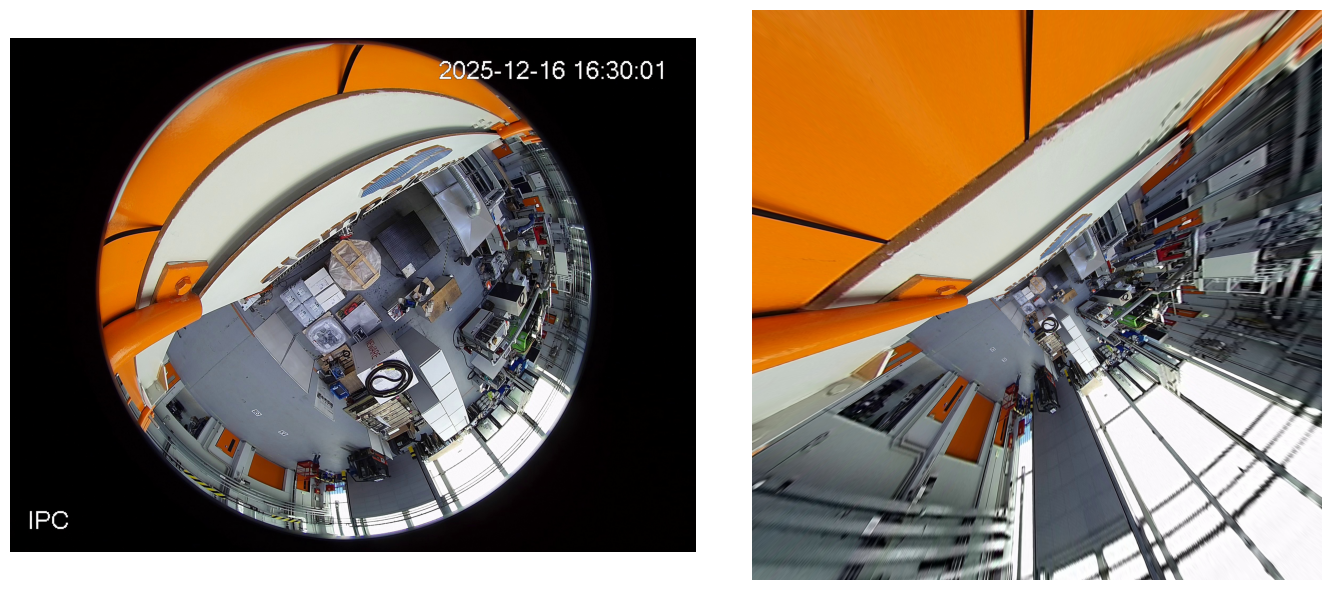

In [19]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708
}

fisheye_img = cv2.imread(r"C:\Users\Nahush\Desktop\Master thesis sentics\Test\fisheye_aruco_capture\fisheye_233_2.jpg")
Hf, Wf = fisheye_params["height"], fisheye_params["width"]
cx_f, cy_f = fisheye_params["cx"], fisheye_params["cy"]
radius, theta_max = fisheye_params["radius"], fisheye_params["theta_max_rad"]


rect_w, rect_h = 2560, 2560
fov = 160.0
fov_RAD = np.deg2rad(fov)
focal = (rect_w / 2) / np.tan(fov_RAD / 2)

K_rect = np.array([[focal, 0.0, rect_w / 2],
                   [0.0, focal, rect_h / 2],
                   [0.0, 0.0, 1.0]])

f_fish = radius / theta_max
K_fish = np.array([[f_fish, 0.0, cx_f],
                   [0.0, f_fish, cy_f],
                   [0.0, 0.0, 1.0]])
D_fish = np.zeros((4, 1)) 


balance = 1.0
dim_rect = (rect_w, rect_h)
rectilinear = cv2.fisheye.undistortImage(fisheye_img, K_fish, D_fish, Knew=K_rect, new_size=dim_rect)




fisheye_rgb = cv2.cvtColor(fisheye_img, cv2.COLOR_BGR2RGB)
rect_rgb = cv2.cvtColor(rectilinear, cv2.COLOR_BGR2RGB)
cv2.imwrite("aruco2_233.jpg", cv2.cvtColor(rect_rgb,cv2.COLOR_BGR2RGB))
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(fisheye_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rect_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()




(12, 1, 2)
Fisheye point (1296.0, 972.0) Rectified point (1280.0, 1280.0)
Fisheye point (1600.0, 900.0) Rectified point (1404.0, 1250.0)
Fisheye point (1000.0, 1200.0) Rectified point (1153.0, 1377.0)
Fisheye point (1296.0, 500.0) Rectified point (1280.0, 1057.0)
Fisheye point (1295.0, 1600.0) Rectified point (1279.0, 1660.0)
Fisheye point (1200.0, 1610.0) Rectified point (1219.0, 1681.0)
Fisheye point (1350.0, 1740.0) Rectified point (1330.0, 2004.0)
Fisheye point (1700.0, 250.0) Rectified point (1806.0, 339.0)
Fisheye point (1200.0, 200.0) Rectified point (1185.0, 523.0)
Fisheye point (1700.0, 400.0) Rectified point (1574.0, 862.0)
Fisheye point (1850.0, 1250.0) Rectified point (1610.0, 1445.0)
Fisheye point (2010.0, 900.0) Rectified point (1830.0, 1224.0)


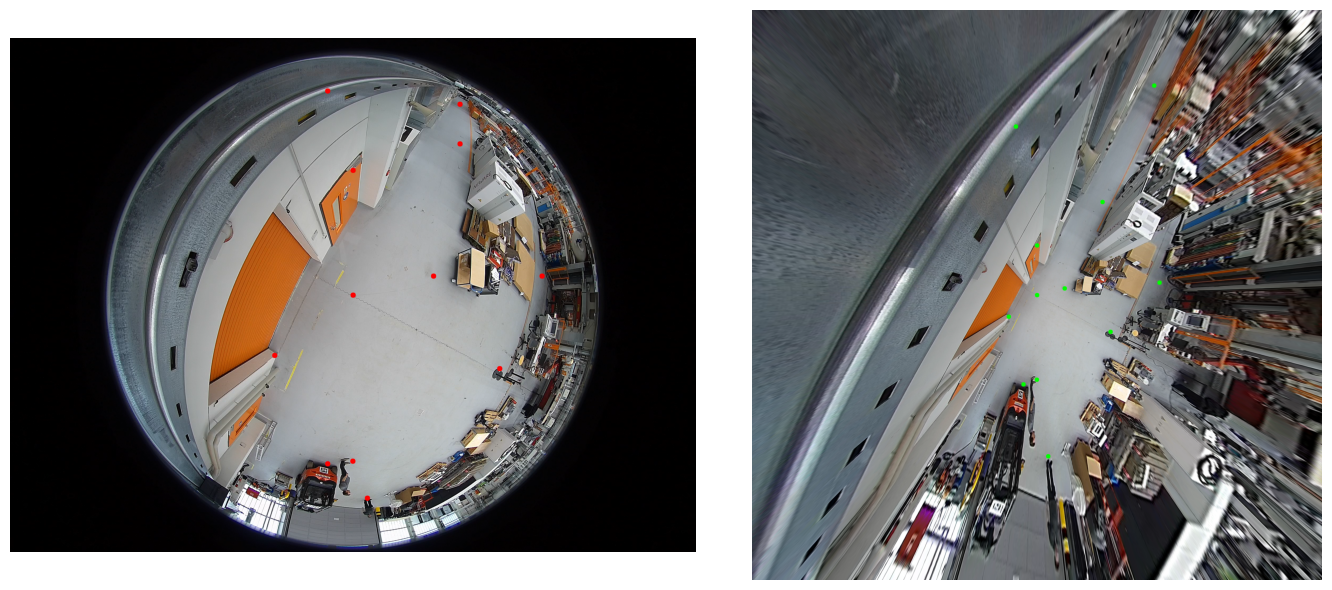

In [7]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708  
}

fisheye_img = cv2.imread("20251104_115055.png")
Hf, Wf = fisheye_params["height"], fisheye_params["width"]
cx_f, cy_f = fisheye_params["cx"], fisheye_params["cy"]
radius, theta_max = fisheye_params["radius"], fisheye_params["theta_max_rad"]


rect_w, rect_h = 2560, 2560
fov = 160.0
fov_RAD = np.deg2rad(fov)
focal = (rect_w / 2) / np.tan(fov_RAD / 2)

K_rect = np.array([[focal, 0.0, rect_w / 2],
                   [0.0, focal, rect_h / 2],
                   [0.0, 0.0, 1.0]])

f_fish = radius / theta_max
K_fish = np.array([[f_fish, 0.0, cx_f],
                   [0.0, f_fish, cy_f],
                   [0.0, 0.0, 1.0]])
D_fish = np.zeros((4, 1)) 


balance = 1.0
dim_rect = (rect_w, rect_h)
rectilinear = cv2.fisheye.undistortImage(fisheye_img, K_fish, D_fish, Knew=K_rect, new_size=dim_rect)


fisheye_points = np.array([
    [1296, 972],     
    [1600, 900],     
    [1000, 1200],    
    [1296, 500],     
    [1295, 1600],
    [1200, 1610],
    [1350, 1740],
    [1700, 250],
    [1200, 200],
    [1700, 400],
    [1850, 1250],
    [2010, 900]     
])

fisheye_points = fisheye_points.astype(np.float32)
fisheye_points = fisheye_points.reshape(-1,1,2)

rect_points = cv2.fisheye.undistortPoints(fisheye_points, K_fish, D_fish, P=K_rect)
print(rect_points.shape)
rect_points = rect_points.reshape(-1, 2)
rect_points = rect_points.astype(np.int32)
fisheye = fisheye_img.copy()
rect = rectilinear.copy()


for (pf, pr) in zip(fisheye_points.reshape(-1, 2), rect_points):
    cv2.circle(fisheye, (int(pf[0]), int(pf[1])), 10, (0, 0, 255), -1)
    cv2.circle(rect, (int(pr[0]), int(pr[1])), 10, (0, 255, 0), -1)
    print(f"Fisheye point ({pf[0]:.1f}, {pf[1]:.1f}) Rectified point ({pr[0]:.1f}, {pr[1]:.1f})")


fisheye_rgb = cv2.cvtColor(fisheye, cv2.COLOR_BGR2RGB)
rect_rgb = cv2.cvtColor(rect, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(fisheye_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rect_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()




In [1]:
import numpy as np

Wr, Hr = 1280, 720
fov = 95.0
cx_r, cy_r = Wr / 2, Hr / 2
f = (Wr / 2) / np.tan(np.deg2rad(fov / 2))

K = np.array([
    [f, 0, cx_r],
    [0, f, cy_r],
    [0, 0, 1]
])

print(K)


[[586.45195137   0.         640.        ]
 [  0.         586.45195137 360.        ]
 [  0.           0.           1.        ]]


In [ ]:

img = cv2.imread("aruco4_229.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray = clahe.apply(gray)

blur = cv2.GaussianBlur(gray, (7, 7), 0)
edges = cv2.Canny(blur, 60, 160, L2gradient=True)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
edges = cv2.morphologyEx(edges, cv2.MORPH_DILATE, kernel)

contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

vis = img.copy()

for cnt in contours:
    peri = cv2.arcLength(cnt, True)
    if peri < 50:
        continue

    approx = cv2.approxPolyDP(cnt, 0.07 * peri, True)

    if len(approx) != 4 or not cv2.isContourConvex(approx):
        continue

    poly_area = cv2.contourArea(approx)
    if poly_area < 50 or poly_area > 1000:
        continue

    pts = approx.reshape(4,2)

    # -------------------------------
    # FILTER 1: Minimum edge length
    # -------------------------------
    edges_len = [np.linalg.norm(pts[i] - pts[(i+1)%4]) for i in range(4)]
    min_edge = min(edges_len)
    max_edge = max(edges_len)

    if min_edge < 15:
        continue

    # -------------------------------
    # FILTER 2: Square-like consistency
    # -------------------------------
    if min_edge / max_edge < 0.6:
        continue

    # -------------------------------
    # BORDER vs INTERIOR CONTRAST
    # -------------------------------
    mask = np.zeros(gray.shape, dtype=np.uint8)
    cv2.drawContours(mask, [approx], -1, 255, -1)

    eroded = cv2.erode(mask, np.ones((5,5), np.uint8))
    border = mask - eroded

    mean_border = cv2.mean(gray, mask=border)[0]
    mean_inside = cv2.mean(gray, mask=eroded)[0]

    contrast = abs(mean_inside - mean_border)
    if contrast < 40:
        continue

    # -------------------------------
    # FILTER 3: Border thickness ratio
    # -------------------------------
    border_area = cv2.countNonZero(border)
    inside_area = cv2.countNonZero(eroded)
    border_ratio = border_area / (border_area + inside_area)

    if border_ratio < 0.25 or border_ratio > 0.6:
        continue

    # -------------------------------
    # FILTER 4: Interior texture
    # -------------------------------
    inside_pixels = gray[eroded > 0]
    if np.std(inside_pixels) < 10:
        continue

    # ✅ FINAL: Marker detected
    cv2.drawContours(vis, [approx], -1, (0,255,0), 3)

    for (x,y) in pts:
        cv2.circle(vis, (int(x),int(y)), 5, (0,0,255), -1)

    print(f"MARKER | area={poly_area:.1f}, contrast={contrast:.1f}, border_ratio={border_ratio:.2f}")

plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
